In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style = "whitegrid")

In [15]:
df = pd.read_csv(
    "../data/processed/loan_2018q2_clean.csv",
    parse_dates=["issue_d", "earliest_cr_line"],
    low_memory=False
)

### Task 1

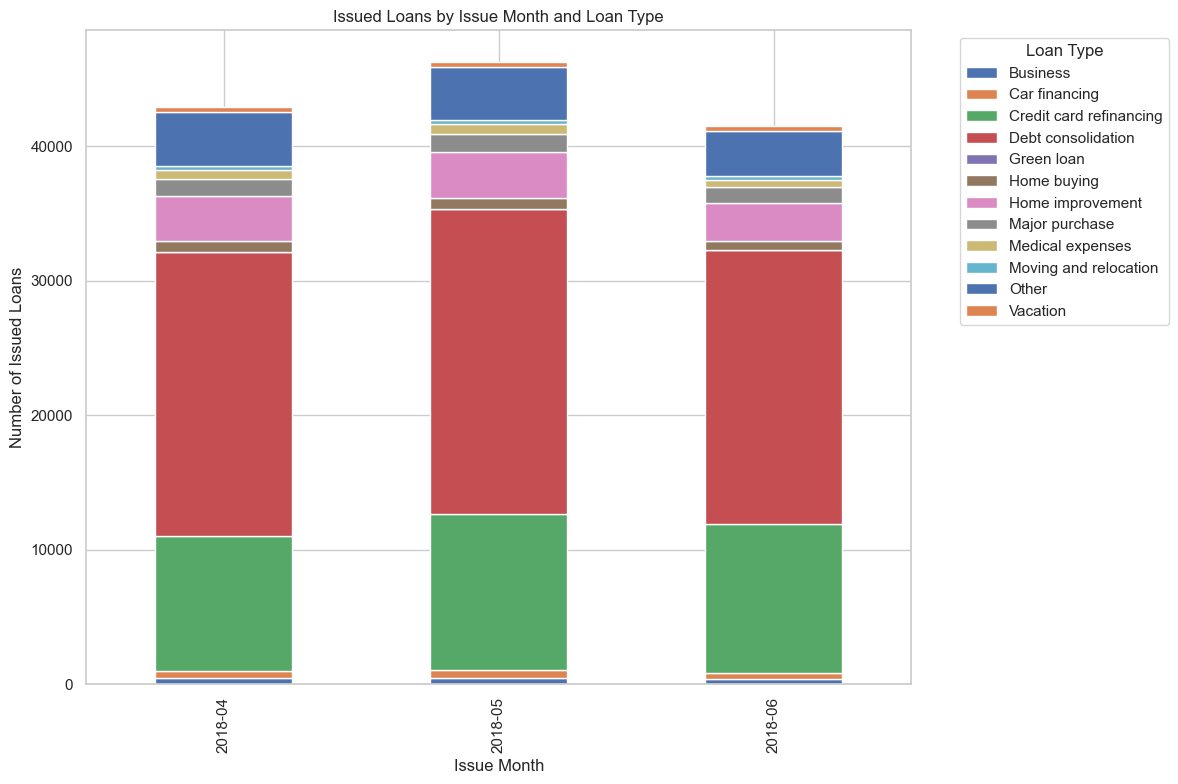

In [16]:
df["issue_month"] = df["issue_d"].dt.to_period("M").astype(str)

monthly_loans = (
  df.groupby(["issue_month", "title"])
  .size()
  .reset_index(name = "loan_count")
  .pivot(index = "issue_month", columns = "title", values = "loan_count")
  .fillna(0)
) 

monthly_loans.plot(
  kind = "bar",
  stacked = True,
  figsize = (12,8)
)

plt.title("Issued Loans by Issue Month and Loan Type")
plt.xlabel("Issue Month")
plt.ylabel("Number of Issued Loans")
plt.legend(title = "Loan Type", bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.tight_layout()
plt.show()



##### **Observations**
Loan issuance volume is highest in May 2018. Portfolio strongly concentrates in two loan types - Debt consolidation and Credit card refinancing.
Overall, portfolio composition remains stable across months.

### Task 2


In [17]:
df["title"].value_counts(normalize=True)

loan_types = [
  "Debt consolidation",
  "Credit card refinancing",
  "Home improvement"
]

df_task2 = df[df["title"].isin(loan_types)]

#### Average profile of borrower


In [18]:
borrower_profile = df_task2.groupby("title").agg(
    borrower_count=("title", "size"),
    median_income=("annual_inc", "median"),
    avg_dti=("dti", "mean"),
    median_loan_to_income=("loan_to_income", "median"),
    avg_emp_length=("emp_length", "mean"),
    avg_loan_amnt=("loan_amnt", "mean"),
    avg_int_rate=("int_rate", "mean"),
    avg_credit_history_months=("credit_history_months", "mean"),
    avg_revol_util=("revol_util", "mean"),
    avg_delinq_2yrs=("delinq_2yrs", "mean"),
    avg_inq_last_6mths=("inq_last_6mths", "mean")
).round(2)

borrower_profile.T

title,Credit card refinancing,Debt consolidation,Home improvement
borrower_count,32822.00,64141.00,9652.00
median_income,65000.00,65000.00,75000.00
avg_dti,19.47,20.47,18.47
median_loan_to_income,0.20,0.23,0.17
avg_emp_length,5.69,6.07,6.78
avg_loan_amnt,15484.50,17263.27,15983.18
avg_int_rate,11.34,13.22,11.87
avg_credit_history_months,186.95,193.87,210.59
avg_revol_util,48.00,44.97,37.31
avg_delinq_2yrs,0.19,0.24,0.31


##### Observations
Home Improvement borrowers appear to be the most established group, showing higher incomes, lower debt-to-income ratios, longer employment and credit histories, and lower revolving credit utilization. However, they also show slightly higher recent inquiries and delinquency history, so they should not be interpreted as lower risk across every metric.
Debt Consolidation borrowers show the highest debt burden, largest loan amounts, and highest interest rates, suggesting a relatively riskier borrower segment.
Credit Card Refinancing borrowers have the lowest average interest rate and lowest missed payment history, but the highest revolving utilization among the three groups.
Overall, borrower profiles differ meaningfully across loan purposes, indicating that loan type may provide useful information for borrower segmentation and risk assessment.

##### Geographic distribution

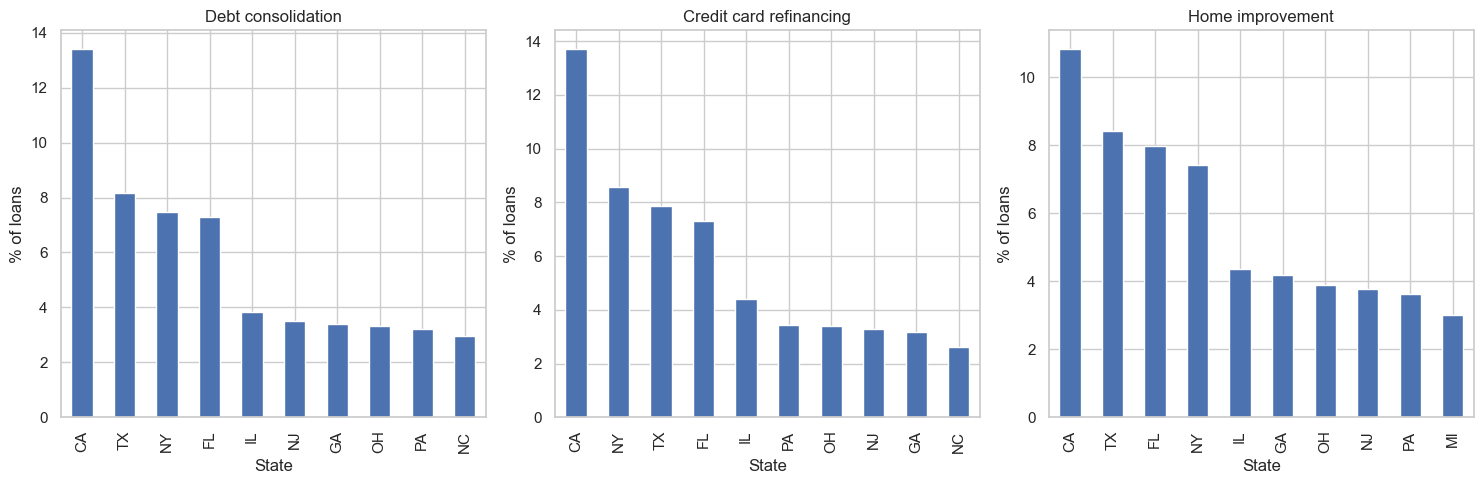

In [19]:
top_states = (
  df_task2
  .groupby("title")["addr_state"]
  .value_counts(normalize = True)
  .mul(100)
  .round(2)
  .groupby(level = 0)
  .head(10)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, title in zip(axes, loan_types):
  data = (
    top_states.loc[title]
    .sort_values(ascending = False)
  )
  data.plot(
    kind = "bar",
    ax = ax
  )
  ax.set_title(title)
  ax.set_ylabel("% of loans")
  ax.set_xlabel("State")

plt.tight_layout()
plt.show()

##### Observations
Geographical distributions are similar across the selected loan types.
California represents the largest share of loans in all three segments, followed by Texas, Florida, and New York.
This likely reflects the larger populations and borrowing activity in these states.

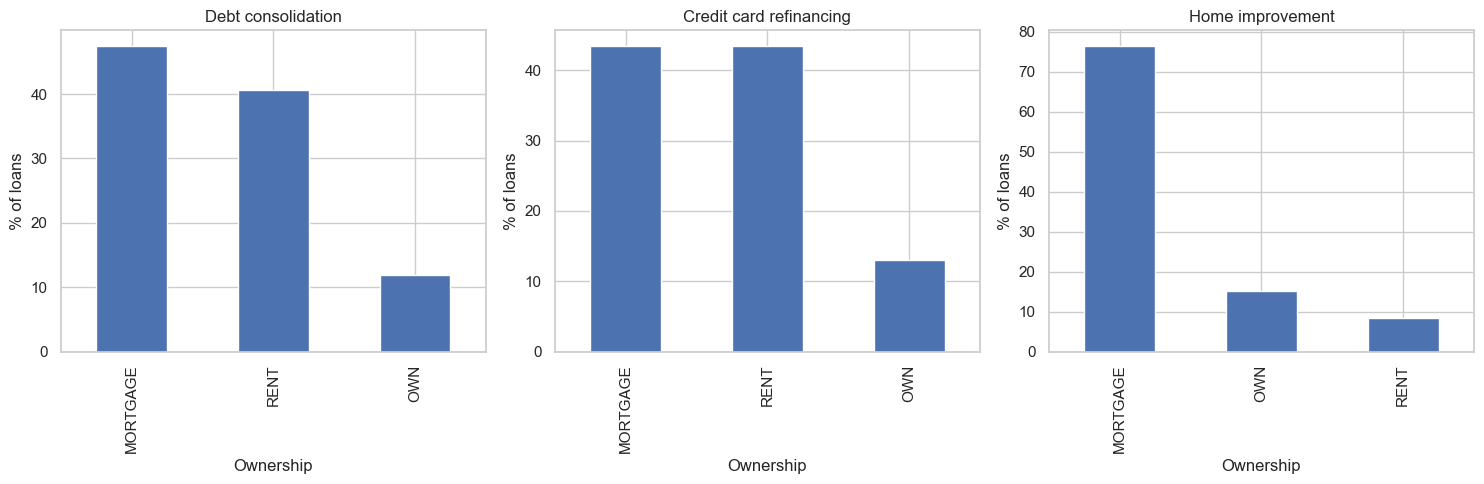

In [20]:
# ANY removed because it is basically 0 for all
home_ownership = (
 df_task2
.loc[df_task2["home_ownership"] != "ANY"]
.groupby("title")["home_ownership"]
.value_counts(normalize=True)
.mul(100)
.round(2)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, title in zip(axes, loan_types):
  data = (
    home_ownership.loc[title]
    .sort_values(ascending = False)
  )
  data.plot(
    kind = "bar",
    ax = ax
  )
  ax.set_title(title)
  ax.set_ylabel("% of loans")
  ax.set_xlabel("Ownership")

plt.tight_layout()
plt.show()

##### Observations
Home ownership patterns differ substantially across the selected loan types. 
Debt Consolidation and Credit Card Refinancing borrowers show similar distributions, with most borrowers either holding a mortgage or renting. 
In contrast, Home Improvement loans are overwhelmingly concentrated among borrowers with mortgages.
This dominance suggests these loans appear to be primarily used by established homeowners.

#### Portfolio Overview

In [21]:
portfolio_summary = df_task2.groupby("title").agg(
    loan_count=("loan_amnt", "size"),
    total_issued_amount=("loan_amnt", "sum"),
    avg_loan_amount=("loan_amnt", "mean"),
    median_loan_amount=("loan_amnt", "median"),
    avg_term_months=("term", "mean"),
    avg_interest_rate=("int_rate", "mean"),
    avg_installment=("installment", "mean"),
    non_performing_rate=("non_performing", "mean"),
    median_loan_to_income=("loan_to_income", "median"),
    median_installment_to_income_pct=("installment_to_income_pct", "median"),
    pct_60_month_term=("term", lambda x: (x == 60).mean() * 100),
).round(2)

portfolio_summary.T

title,Credit card refinancing,Debt consolidation,Home improvement
loan_count,32822.00,64141.00,9652.00
total_issued_amount,508232150.00,1107283500.00,154269700.00
avg_loan_amount,15484.50,17263.27,15983.18
median_loan_amount,12500.00,15000.00,12500.00
avg_term_months,42.19,44.22,43.63
avg_interest_rate,11.34,13.22,11.87
avg_installment,452.12,502.42,453.20
non_performing_rate,0.02,0.04,0.04
median_loan_to_income,0.20,0.23,0.17
median_installment_to_income_pct,7.05,7.98,5.77


##### Observations

Debt Consolidation is by far the largest portfolio segment, with the highest loan count, total issued amount, average loan amount, and median loan amount. This makes it the largest contributor to portfolio exposure among the selected loan types.

Debt Consolidation also has the highest average interest rate, highest median loan-to-income ratio, highest installment-to-income burden, and the largest share of 60-month loans. This suggests a relatively higher-risk and longer-duration portfolio segment.

Credit Card Refinancing has the lowest average interest rate and lowest non-performing rate, indicating a comparatively stronger-performing segment. It also has a smaller average loan amount than Debt Consolidation.

Home Improvement loans have a smaller portfolio size but a borrower profile that appears more established. They have the lowest median loan-to-income and installment-to-income ratios, suggesting lower repayment burden relative to income.

Overall, loan type appears to meaningfully differentiate portfolio size, pricing, maturity, borrower affordability, and performance risk.



In [22]:
display(
  pd.crosstab(
    df_task2["title"],
    df_task2["grade"],
    normalize="index"
).mul(100).round(2).T
)

display(
  pd.crosstab(
    df_task2["title"],
    df_task2["loan_status"],
    normalize="index"
).mul(100).round(2).T
)



title,Credit card refinancing,Debt consolidation,Home improvement
grade,,,
A,33.60,21.02,28.52
B,30.88,28.10,30.73
C,23.71,29.00,26.37
D,9.49,16.55,11.86
E,1.88,4.16,2.13
F,0.39,0.97,0.31
G,0.04,0.20,0.07


title,Credit card refinancing,Debt consolidation,Home improvement
loan_status,,,
Charged Off,0.80,1.40,1.50
Current,89.36,86.27,84.54
Fully Paid,7.40,8.75,10.69
In Grace Period,0.81,1.13,0.89
Late (16-30 days),0.33,0.50,0.44
Late (31-120 days),1.29,1.95,1.94


##### Observation
Debt Consolidation has a larger share of lower grades such as D, E, F, and G, while Credit Card Refinancing has the highest share of grade A loans. This supports the pricing pattern, where Debt Consolidation receives higher average interest rates and Credit Card Refinancing receives lower average rates.

Credit Card Refinancing shows the lowest non-performing share among the three groups. It has the lowest charged-off rate and lower late-loan shares than Debt Consolidation and Home Improvement.
Debt Consolidation and Home Improvement have similar non-performing patterns, with higher charged-off and late loan shares than Credit Card Refinancing.
Overall, Credit Card Refinancing appears to be the strongest-performing segment in this snapshot, while Debt Consolidation and Home Improvement show slightly weaker early performance.
Most loans in all three selected loan types are still in "Current", which means portfolio is not fully seasoned. Because of this, performance conclusions should be interpreted carefully.

Summary
- Debt Consolidation: largest and riskiest/most expensive segment.
- Credit Card Refinancing: strongest early performance and lowest pricing.
- Home Improvement: smaller, more homeowner-oriented, more established borrower profile, lower repayment burden.
